# Τμηματοποίηση Συνδρομητών Τηλεπικοινωνιών με Ομαδοποίηση k-Means


## Περίληψη για τη Διοίκηση

Μια εταιρεία τηλεπικοινωνιών θέλει να ομαδοποιήσει τη βάση συνδρομητών συμβολαίου της σε συμπεριφορικά τμήματα, ώστε να στοχεύσει προσφορές διατήρησης και να προσαρμόσει τα πακέτα δεδομένων. Αυτό το notebook δημιουργεί ένα συνθετικό σύνολο δεδομένων χρήσης συνδρομητών και στη συνέχεια εκτελεί μια πλήρη ροή τμηματοποίησης k-means σε Base SAS: τυποποιεί τους παράγοντες χρήσης με την **PROC STDIZE**, επιλέγει τον αριθμό συστάδων συγκρίνοντας το στατιστικό ψευδο-F για υποψήφια k με την **PROC FASTCLUS**, προσαρμόζει ένα τελικό μοντέλο σταθμισμένο κατά FREQ που βαθμολογεί κάθε συνδρομητή, και εξάγει τα εκπαιδευμένα κεντροειδή ώστε το στιγμιότυπο του επόμενου μήνα να μπορεί να βαθμολογηθεί χωρίς επανα-ομαδοποίηση. Το αποτέλεσμα είναι μια επαναχρησιμοποιήσιμη τμηματοποίηση που αντιστοιχίζει την ακατέργαστη τηλεμετρία χρήσης σε ένα πλάνο διατήρησης πελατών.

## Πηγές Δεδομένων

**Συνθετικό σύνολο δεδομένων: `WORK.SUBSCRIBERS`** (100 συνδρομητές κινητής τηλεφωνίας συμβολαίου, δημιουργημένοι εν σειρά με `call streaminit(20260531)`)

| Μεταβλητή | Τύπος | Ρόλος | Περιγραφή |
|----------|------|------|-------------|
| `cust_id` | Χαρακτήρας | Αναγνωριστικό | Αναγνωριστικό συνδρομητή (π.χ. `SUB000123`) |
| `tenure_months` | Αριθμός | Είσοδος διαστήματος | Μήνες ενεργής γραμμής (1-72) |
| `data_gb` | Αριθμός | Είσοδος διαστήματος | Μέση μηνιαία χρήση δεδομένων κινητής, σε GB |
| `voice_min` | Αριθμός | Είσοδος διαστήματος | Μέσα μηνιαία λεπτά φωνής |
| `intl_min` | Αριθμός | Είσοδος διαστήματος | Μέσα μηνιαία διεθνή λεπτά |
| `support_calls` | Αριθμός | Είσοδος διαστήματος | Επικοινωνίες με την υποστήριξη τις τελευταίες 90 ημέρες |
| `monthly_charge` | Αριθμός | Είσοδος διαστήματος | Τρέχων μηνιαίος λογαριασμός, σε δολάρια |
| `plan_tier` | Χαρακτήρας | Προφίλ | Πακέτο χρέωσης: `Βασικό`, `Plus`, ή `Απεριόριστο` |
| `n_lines` | Αριθμός | Βάρος FREQ | Γραμμές στον λογαριασμό |

Τρία λανθάνοντα προφίλ συμπεριφοράς είναι ενσωματωμένα στη γεννήτρια δεδομένων - *χαμηλής χρήσης/value*, *υψηλής χρήσης δεδομένων/streaming*, και *συχνής επικοινωνίας/κίνδυνος διαρροής* - ώστε η ομαδοποίηση να έχει πραγματική δομή προς ανάκτηση. Οι παράγοντες διαστήματος τροφοδοτούν το μοντέλο k-means· η `plan_tier` κρατείται εκτός για μεταγενέστερη κατάρτιση προφίλ, και η `n_lines` σταθμίζει κάθε λογαριασμό ανάλογα με τον αριθμό γραμμών του. Δεν χρησιμοποιούνται εξωτερικά αρχεία ή πρόσβαση στο δίκτυο.

## Συμπεριφορική τμηματοποίηση σε πέντε βήματα

Οι εταιρείες κινητής τηλεφωνίας διαχειρίζονται εκατομμύρια γραμμές συμβολαίου, και μια ενιαία στρατηγική διατήρησης σπαταλά περιθώριο σε πελάτες που θα έμεναν ούτως ή άλλως, ενώ χάνει αυτούς που πρόκειται να αποχωρήσουν. Η **συμπεριφορική τμηματοποίηση** μετατρέπει την ακατέργαστη τηλεμετρία χρήσης σε λίγους αξιοποιήσιμους τύπους πελατών: χρήστες *χαμηλής χρήσης/value* που είναι ευαίσθητοι στην τιμή, *χρήστες υψηλής χρήσης δεδομένων* που αποτελούν καλούς στόχους αναβάθμισης, και λογαριασμούς *συχνής επικοινωνίας/κινδύνου διαρροής* που χρειάζονται προληπτική φροντίδα.

Αυτό το notebook χτίζει την τμηματοποίηση με την `PROC FASTCLUS`, τη διαδικασία k-means (ασύνδετων συστάδων) της SAS. Θα:

1. Δημιουργήσουμε ένα συνθετικό αλλά ρεαλιστικό σύνολο δεδομένων χρήσης συνδρομητών.
2. Τοποθετήσουμε τους παράγοντες χρήσης σε κοινή κλίμακα με την **PROC STDIZE**.
3. **Επιλέξουμε τον αριθμό συστάδων** συγκρίνοντας το στατιστικό ψευδο-F για υποψήφια k.
4. Προσαρμόσουμε ένα τελικό μοντέλο σταθμισμένο κατά FREQ που **βαθμολογεί** κάθε συνδρομητή και κάνει προφίλ των τμημάτων.
5. **Εξάγουμε τα εκπαιδευμένα κεντροειδή** ώστε το μοντέλο να μπορεί να επαναεφαρμοστεί στο στιγμιότυπο του επόμενου μήνα.

## Βήμα 1 - Δημιουργία συνθετικής βάσης συνδρομητών

Προσομοιώνουμε 100 συνδρομητές συμβολαίου. Κάθε ένας προέρχεται από ένα από τα τρία λανθάνοντα προφίλ με διαφορετικά χαρακτηριστικά χρήσης, ώστε να υπάρχει πραγματική δομή συστάδων προς ανάκτηση. Σταθεροποιούμε τη ροή τυχαίων αριθμών με `call streaminit` για αναπαραγωγιμότητα και περιορίζουμε τις προσομοιωμένες τιμές σε εύλογα εύρη με `max`/`min`/`round`.

Η ονομαστική μεταβλητή `plan_tier` συσχετίζεται με το λανθάνον προφίλ (οι streamers τείνουν προς το *Απεριόριστο*· οι χρήστες χαμηλής χρήσης προς το *Βασικό*), και η `n_lines` θα χρησιμεύσει αργότερα ως βάρος FREQ ώστε οι οικογενειακοί λογαριασμοί πολλαπλών γραμμών να μετρούν αναλογικά.

In [1]:
ΔΕΔΟΜΕΝΑ subscribers;
    CALL streaminit(20260531);
    LENGTH cust_id $9 plan_tier $30;
    ΕΠΑΝΑΛΗΨΗ i = 1 ΕΩΣ 100;
        cust_id = cats('SUB', PUT(i, z6.));

        /* Τρια λανθανοντα προφιλ συμπεριφορας, με ανιση συχνοτητα εμφανισης */
        u = rand('uniform');
        ΕΑΝ u < 0.45 ΤΟΤΕ profile = 1;        /* χαμηλης χρησης / value        */
        ΑΛΛΙΩΣ ΕΑΝ u < 0.80 ΤΟΤΕ profile = 2;   /* υψηλης χρησης δεδομενων / streamer   */
        ΑΛΛΙΩΣ profile = 3;                    /* συχνη επικοινωνια / κινδυνος διαρροης  */

        ΕΑΝ profile = 1 ΤΟΤΕ ΕΠΑΝΑΛΗΨΗ;
            tenure_months  = round(MIN(72, MAX(1, rand('normal', 30, 14))));
            data_gb        = MAX(0.2, rand('normal', 3,  1.5));
            voice_min      = MAX(0,   rand('normal', 180, 60));
            intl_min       = MAX(0,   rand('exponential') * 8);
            support_calls  = rand('poisson', 0.6);
            monthly_charge = MAX(15, rand('normal', 45, 8));
        ΤΕΛΟΣ;
        ΑΛΛΙΩΣ ΕΑΝ profile = 2 ΤΟΤΕ ΕΠΑΝΑΛΗΨΗ;
            tenure_months  = round(MIN(72, MAX(1, rand('normal', 40, 16))));
            data_gb        = MAX(0.2, rand('normal', 22, 6));
            voice_min      = MAX(0,   rand('normal', 320, 90));
            intl_min       = MAX(0,   rand('exponential') * 25);
            support_calls  = rand('poisson', 1.2);
            monthly_charge = MAX(15, rand('normal', 85, 12));
        ΤΕΛΟΣ;
        ΑΛΛΙΩΣ ΕΠΑΝΑΛΗΨΗ;
            tenure_months  = round(MIN(72, MAX(1, rand('normal', 12, 8))));
            data_gb        = MAX(0.2, rand('normal', 9,  4));
            voice_min      = MAX(0,   rand('normal', 240, 80));
            intl_min       = MAX(0,   rand('exponential') * 15);
            support_calls  = rand('poisson', 5.5);
            monthly_charge = MAX(15, rand('normal', 70, 18));
        ΤΕΛΟΣ;

        /* Πακετο συσχετισμενο με το προφιλ */
        p = rand('uniform');
        ΕΑΝ profile = 1 ΤΟΤΕ
            plan_tier = ifc(p < 0.70, 'Βασικό', ifc(p < 0.95, 'Plus', 'Απεριόριστο'));
        ΑΛΛΙΩΣ ΕΑΝ profile = 2 ΤΟΤΕ
            plan_tier = ifc(p < 0.65, 'Απεριόριστο', ifc(p < 0.90, 'Plus', 'Βασικό'));
        ΑΛΛΙΩΣ
            plan_tier = ifc(p < 0.45, 'Plus', ifc(p < 0.80, 'Απεριόριστο', 'Βασικό'));

        /* Γραμμες στον λογαριασμο: οι περισσοτερες ειναι μονη γραμμη */
        n_lines = 1 + rand('binomial', 0.35, 3);

        /* Στρογγυλοποιηση χρηματικων / τιμων χρησης σε ρεαλιστικη ακριβεια */
        data_gb        = round(data_gb, 0.1);
        voice_min      = round(voice_min);
        intl_min       = round(intl_min);
        monthly_charge = round(monthly_charge, 0.01);

        ΕΞΟΔΟΣ;
    ΤΕΛΟΣ;
    ΑΦΑΙΡΕΣΗ i u p profile;
    ΕΤΙΚΕΤΑ cust_id="Αναγνωριστικό Συνδρομητή" plan_tier="Πακέτο" tenure_months="Μήνες Παραμονής"
          data_gb="Δεδομένα (GB)" voice_min="Λεπτά Φωνής" intl_min="Διεθνή Λεπτά"
          support_calls="Κλήσεις Υποστήριξης" monthly_charge="Μηνιαία Χρέωση" n_lines="Αριθμός Γραμμών";
ΕΚΤΕΛΕΣΗ;

ΔΙΑΔΙΚΑΣΙΑ ΕΚΤΥΠΩΣΗ ΔΕΔΟΜΕΝΑ=subscribers(obs=10) noobs;
    ΕΤΙΚΕΤΑ cust_id="Αναγνωριστικό Συνδρομητή" plan_tier="Πακέτο" tenure_months="Μήνες Παραμονής"
          data_gb="Δεδομένα (GB)" voice_min="Λεπτά Φωνής" intl_min="Διεθνή Λεπτά"
          support_calls="Κλήσεις Υποστήριξης" monthly_charge="Μηνιαία Χρέωση" n_lines="Αριθμός Γραμμών";
    TITLE 'Δείγμα Συνθετικών Εγγραφών Χρήσης Συνδρομητών';
ΕΚΤΕΛΕΣΗ;

                                     Δείγμα Συνθετικών Εγγραφών Χρήσης Συνδρομητών                                      

                       Αναγνωριστικό Συνδρομητή                  Πακέτο                Μήνες Παραμονής          Δεδομένα (GB)            Λεπτά Φωνής             Διεθνή Λεπτά                    Κλήσεις Υποστήριξης               Μηνιαία Χρέωση                Αριθμός Γραμμών
SUB000001                                        Βασικό                                             15                    9.7                    114                        5                                     11                        57.07                              2
SUB000002                                        Βασικό                                             39                    0.6                    214                        2                                      1                        35.88                              3
SUB000003                                        Απεριόριστ


NOTE: DATA subscribers


NOTE: Wrote subscribers (100 rows, 9 columns).
NOTE: DATA elapsed:
  wall  0.03 seconds
  cpu   0.03 seconds
NOTE: PROC PRINT data=subscribers

NOTE: PROC PRINT completed: 10 observations printed, 9 variables


## Βήμα 2 - Τοποθέτηση των παραγόντων σε κοινή κλίμακα

Η k-means χρησιμοποιεί ευκλείδεια απόσταση, οπότε μια μεταβλητή μεγάλου μεγέθους όπως τα λεπτά φωνής θα κυριαρχούσε έναντι μιας μικρού μεγέθους όπως οι κλήσεις υποστήριξης, αν κάναμε ομαδοποίηση στις ακατέργαστες τιμές. Η καθιερωμένη λύση είναι να τυποποιήσουμε πρώτα κάθε παράγοντα διαστήματος σε μέσο όρο 0 και τυπική απόκλιση 1. Η **PROC STDIZE** με `METHOD=STD` κάνει ακριβώς αυτό, γράφοντας το τυποποιημένο (z-score) αντίγραφο στο `WORK.SUBS_STD`. Μεταφέρουμε τις `cust_id`, `plan_tier`, και `n_lines` αναλλοίωτες ώστε να είναι διαθέσιμες για στάθμιση και κατάρτιση προφίλ αργότερα.

In [2]:
ΔΙΑΔΙΚΑΣΙΑ stdize ΔΕΔΟΜΕΝΑ=subscribers out=subs_std METHOD=std;
    ΜΕΤΑΒΛΗΤΗ tenure_months data_gb voice_min intl_min support_calls monthly_charge;
ΕΚΤΕΛΕΣΗ;

ΔΙΑΔΙΚΑΣΙΑ ΜΕΣΟΙ ΔΕΔΟΜΕΝΑ=subs_std mean std maxdec=3;
    ΜΕΤΑΒΛΗΤΗ tenure_months data_gb voice_min intl_min support_calls monthly_charge;
    ΕΤΙΚΕΤΑ tenure_months="Μήνες Παραμονής" data_gb="Δεδομένα (GB)" voice_min="Λεπτά Φωνής"
          intl_min="Διεθνή Λεπτά" support_calls="Κλήσεις Υποστήριξης" monthly_charge="Μηνιαία Χρέωση";
    TITLE 'Τυποποιημένοι Παράγοντες: Μέσος ~ 0, Τυπική Απόκλιση ~ 1';
ΕΚΤΕΛΕΣΗ;

                                     Δείγμα Συνθετικών Εγγραφών Χρήσης Συνδρομητών                                      

                                Τυποποιημένοι Παράγοντες: Μέσος ~ 0, Τυπική Απόκλιση ~ 1                                

                                                  The MEANS Procedure

 Variable        Label                                           Mean     Std Dev
 --------------------------------------------------------------------------------
 tenure_months   Μήνες Παραμονής                                0.000       1.000
 data_gb         Δεδομένα (GB)                                 -0.000       1.000
 voice_min       Λεπτά Φωνής                                   -0.000       1.000
 intl_min        Διεθνή Λεπτά                                   0.000       1.000
 support_calls   Κλήσεις Υποστήριξης                           -0.000       1.000
 monthly_charge  Μηνιαία Χρέωση                                 0.000       1.000
 ----------------------------


NOTE: PROC STDIZE data=subscribers

NOTE: PROC STDIZE: Wrote 100 rows to subs_std
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


## Βήμα 3 - Πόσα τμήματα; Σύγκριση του ψευδο-F για υποψήφια k

Αντί να μαντέψουμε τον αριθμό συστάδων, προσαρμόζουμε την FASTCLUS για κάθε υποψήφιο k και διαβάζουμε τα στατιστικά προσαρμογής μοντέλου που αναφέρει. Το **στατιστικό ψευδο-F** (λόγος διακύμανσης μεταξύ συστάδων προς διακύμανση εντός συστάδων) και ο **συνολικός R-τετράγωνο** ανταμείβουν και οι δύο τον διαχωρισμό· ένα καλό k είναι εκεί όπου το ψευδο-F είναι υψηλό και η προσθήκη άλλης συστάδας αποδίδει φθίνουσες αποδόσεις. Ένας σύντομος βρόχος μακροεντολής εκτελεί k = 2, 3, 4 με `MAXITER=50` και `CONVERGE=0` (επανάληψη έως σταθεροποίηση). Συγκρίνετε τις γραμμές `Pseudo F Statistic` και `Overall R-Squared` στις τρεις παρακάτω λίστες: η ενσωματωμένη δομή έχει τρία λανθάνοντα προφίλ, και το k = 3 δίνει την ισχυρότερη, πιο ισορροπημένη λύση.

In [3]:
%macro pick_k;
    %ΕΠΑΝΑΛΗΨΗ k = 2 %ΕΩΣ 4;
        ΔΙΑΔΙΚΑΣΙΑ FASTCLUS ΔΕΔΟΜΕΝΑ=subs_std maxclusters=&k MAXITER=50 CONVERGE=0;
            ΜΕΤΑΒΛΗΤΗ tenure_months data_gb voice_min intl_min support_calls monthly_charge;
            ΕΤΙΚΕΤΑ tenure_months="Μήνες Παραμονής" data_gb="Δεδομένα (GB)" voice_min="Λεπτά Φωνής"
                  intl_min="Διεθνή Λεπτά" support_calls="Κλήσεις Υποστήριξης" monthly_charge="Μηνιαία Χρέωση";
            TITLE "Υποψήφιος Αριθμός Συστάδων: k = &k";
        ΕΚΤΕΛΕΣΗ;
    %ΤΕΛΟΣ;
%mend pick_k;
%pick_k;

                                Τυποποιημένοι Παράγοντες: Μέσος ~ 0, Τυπική Απόκλιση ~ 1                                


                                                 The FASTCLUS Procedure                                                 
                                   Replace=FULL  Radius=0  Maxclusters=2  Maxiter=50                                    

                                                    Cluster Summary                                                     

Cluster     Frequency        RMS Std   Maximum Distance        Nearest       Centroid
                           Deviation          from Seed        Cluster       Distance
--------------------------------------------------------------------------------
1                  41         0.9639             4.8215              2         2.8826
2                  59         0.6989             4.7667              1         2.8826

                                                Statistics for Variables              


NOTE: PROC FASTCLUS data=subs_std maxclusters=2

NOTE: Using Python/scikit-learn for k-means clustering
NOTE: PROC FASTCLUS: 100 observations, 6 variables, 2 clusters using k-means
NOTE: PROC FASTCLUS data=subs_std maxclusters=3

NOTE: Using Python/scikit-learn for k-means clustering
NOTE: PROC FASTCLUS: 100 observations, 6 variables, 3 clusters using k-means
NOTE: PROC FASTCLUS data=subs_std maxclusters=4

NOTE: Using Python/scikit-learn for k-means clustering
NOTE: PROC FASTCLUS: 100 observations, 6 variables, 4 clusters using k-means


## Βήμα 4 - Προσαρμογή της τελικής τμηματοποίησης και βαθμολόγηση κάθε συνδρομητή

Με το k = 3 επιλεγμένο, προσαρμόζουμε το μοντέλο παραγωγής. Αυτή η εκτέλεση είναι πλήρως αντιπροσωπευτική για μια επιχειρησιακή τμηματοποίηση:

- Η δήλωση `FREQ` σταθμίζει κάθε λογαριασμό κατά `n_lines`, ώστε ένας οικογενειακός λογαριασμός με τέσσερις γραμμές να συνεισφέρει τέσσερις φορές περισσότερο από μία μόνη γραμμή κατά τον υπολογισμό των κεντροειδών.
- Η `OUT=SCORED` γράφει κάθε συνδρομητή με την αντιστοιχισμένη `CLUSTER` και την `DISTANCE` του από το κεντροειδές της συστάδας· η δήλωση `ID` μεταφέρει την `cust_id` σε αυτόν τον βαθμολογημένο πίνακα.
- Η `MEAN=SEG_MEANS` καταγράφει τα κεντροειδή ανά συστάδα (στην τυποποιημένη κλίμακα).
- Η `OUTSEED=SEG_SEEDS` αποθηκεύει τα τελικά κεντροειδή στη μορφή seed που η FASTCLUS μπορεί να διαβάσει ξανά - αυτό είναι το εξαγόμενο μοντέλο που επαναεφαρμόζουμε στο Βήμα 6.

Τα στατιστικά προσαρμογής μοντέλου είχαν ήδη καθοριστεί στη σάρωση του Βήματος 3, οπότε προσθέτουμε εδώ την επιλογή `SHORT` ώστε η λίστα να επικεντρώνεται στα μεγέθη συστάδων και τα κεντροειδή που οδηγούν στην έξοδο βαθμολόγησης.

In [4]:
ΔΙΑΔΙΚΑΣΙΑ FASTCLUS ΔΕΔΟΜΕΝΑ=subs_std maxclusters=3 MAXITER=50 CONVERGE=0 short
        out=scored mean=seg_means outseed=seg_seeds;
    ΜΕΤΑΒΛΗΤΗ tenure_months data_gb voice_min intl_min support_calls monthly_charge;
    ΣΥΧΝΟΤΗΤΕΣ n_lines;
    id cust_id;
    ΕΤΙΚΕΤΑ tenure_months="Μήνες Παραμονής" data_gb="Δεδομένα (GB)" voice_min="Λεπτά Φωνής"
          intl_min="Διεθνή Λεπτά" support_calls="Κλήσεις Υποστήριξης" monthly_charge="Μηνιαία Χρέωση"
          cust_id="Αναγνωριστικό Συνδρομητή" n_lines="Αριθμός Γραμμών";
    TITLE 'Τελική Τμηματοποίηση: k = 3, Στάθμιση FREQ βάσει Αριθμού Γραμμών';
ΕΚΤΕΛΕΣΗ;

ΔΙΑΔΙΚΑΣΙΑ ΕΚΤΥΠΩΣΗ ΔΕΔΟΜΕΝΑ=seg_means noobs;
    ΕΤΙΚΕΤΑ CLUSTER="Συστάδα" tenure_months="Μήνες Παραμονής" data_gb="Δεδομένα (GB)" voice_min="Λεπτά Φωνής"
          intl_min="Διεθνή Λεπτά" support_calls="Κλήσεις Υποστήριξης" monthly_charge="Μηνιαία Χρέωση"
          _freq_="Πλήθος";
    TITLE 'Κεντροειδή Τμημάτων (Τυποποιημένη Κλίμακα)';
ΕΚΤΕΛΕΣΗ;

                                Τυποποιημένοι Παράγοντες: Μέσος ~ 0, Τυπική Απόκλιση ~ 1                                


                                                 The FASTCLUS Procedure                                                 
                                   Replace=FULL  Radius=0  Maxclusters=3  Maxiter=50                                    

                                                    Cluster Summary                                                     

Cluster     Frequency        RMS Std   Maximum Distance        Nearest       Centroid
                           Deviation          from Seed        Cluster       Distance
--------------------------------------------------------------------------------
1                  51         0.5507             2.8651              2         3.1977
2                  31         0.8130             3.4539              3         3.0115
3                  18         0.8596             4.1352              2         3.0115




NOTE: PROC FASTCLUS data=subs_std maxclusters=3

NOTE: Using Python/scikit-learn for k-means clustering
NOTE: PROC FASTCLUS: 100 observations, 6 variables, 3 clusters using k-means
NOTE: PROC PRINT data=seg_means

NOTE: PROC PRINT completed: 3 observations printed, 8 variables


## Βήμα 5 - Προφίλ των τμημάτων σε επιχειρησιακές μονάδες

Ο βαθμολογημένος πίνακας φέρει την ανάθεση `CLUSTER` κάθε συνδρομητή, αλλά στην τυποποιημένη κλίμακα τα κεντροειδή είναι δύσκολο να διαβαστούν. Για να μετατρέψουμε τους αριθμούς συστάδων σε επιχειρησιακές περσόνες, ενώνουμε την ανάθεση πίσω με τον αρχικό πίνακα `subscribers` και κάνουμε προφίλ σε πραγματικές μονάδες - gigabytes, λεπτά και δολάρια. Η PROC MEANS συνοψίζει τους παράγοντες διαστήματος ανά τμήμα, και η PROC FREQ σταυρώνει την εξαιρεθείσα `plan_tier` έναντι του τμήματος για να δείξει τη σύνθεση πακέτου κάθε περσόνας.

                               Προφίλ Τμημάτων: Μέση Χρήση ανά Συστάδα (Αρχικές Μονάδες)                                

                                                  The MEANS Procedure

                            Analysis Variable : tenure_months Μήνες Παραμονής

                                             N
                         Συστάδα           Obs      Mean      Std Dev      Minimum      Maximum
                         ----------------------------------------------------------------------
                         1                  51      33.2         14.7          1.0         61.0
                         2                  31      40.5         14.0         17.0         67.0
                         3                  18      12.7          7.1          1.0         30.0
                         ----------------------------------------------------------------------

                                   Analysis Variable : data_gb Δεδομένα (GB)

                          


NOTE: PROC SORT data=scored

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 100 rows from scored.
NOTE: Wrote scored_keys (100 rows, 11 columns).
NOTE: PROC SORT statement used.
NOTE: PROC SORT data=subscribers

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 100 rows from subscribers.
NOTE: Wrote subs_sorted (100 rows, 9 columns).
NOTE: PROC SORT statement used.
NOTE: DATA profile

NOTE: Stream 1 processed 100 rows, max BY-group size: 1 (O(1) memory verified)
NOTE: Stream 2 processed 100 rows, max BY-group size: 1 (O(1) memory verified)

NOTE: Wrote profile (100 rows, 10 columns).
NOTE: DATA elapsed:
  wall  0.02 seconds
  cpu   0.02 seconds
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.
NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_cluster_plan_tier.spec.json
NOTE: PROC FREQ statement used.


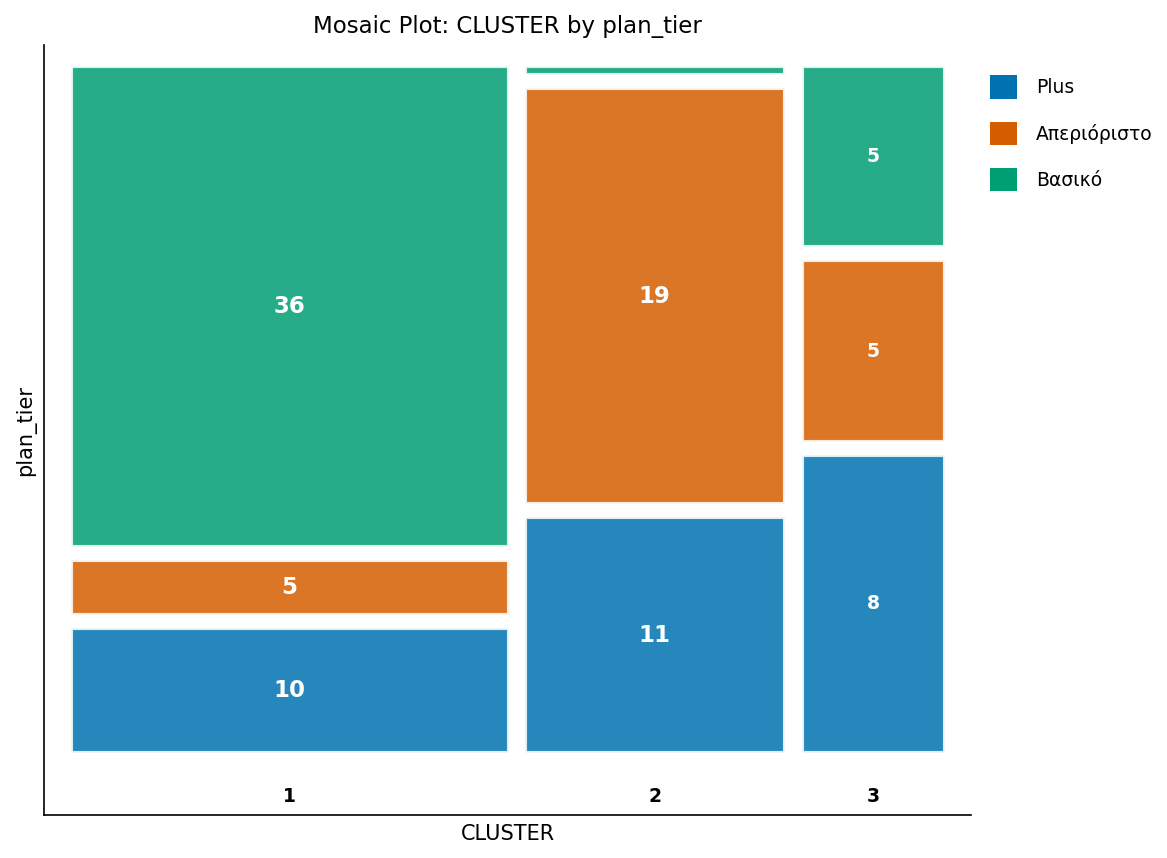

In [5]:
ΔΙΑΔΙΚΑΣΙΑ ΤΑΞΙΝΟΜΗΣΗ ΔΕΔΟΜΕΝΑ=scored out=scored_keys(ΚΡΑΤΗΣΗ=cust_id CLUSTER);
    ΚΑΤΑ cust_id;
ΕΚΤΕΛΕΣΗ;

ΔΙΑΔΙΚΑΣΙΑ ΤΑΞΙΝΟΜΗΣΗ ΔΕΔΟΜΕΝΑ=subscribers out=subs_sorted;
    ΚΑΤΑ cust_id;
ΕΚΤΕΛΕΣΗ;

ΔΕΔΟΜΕΝΑ profile;
    ΣΥΓΧΩΝΕΥΣΗ subs_sorted(IN=a) scored_keys(IN=b);
    ΚΑΤΑ cust_id;
    ΕΑΝ a AND b;
ΕΚΤΕΛΕΣΗ;

ΔΙΑΔΙΚΑΣΙΑ ΜΕΣΟΙ ΔΕΔΟΜΕΝΑ=profile mean std MIN MAX maxdec=1;
    ΚΛΑΣΗ CLUSTER;
    ΜΕΤΑΒΛΗΤΗ tenure_months data_gb voice_min intl_min support_calls monthly_charge;
    ΕΤΙΚΕΤΑ CLUSTER="Συστάδα" tenure_months="Μήνες Παραμονής" data_gb="Δεδομένα (GB)" voice_min="Λεπτά Φωνής"
          intl_min="Διεθνή Λεπτά" support_calls="Κλήσεις Υποστήριξης" monthly_charge="Μηνιαία Χρέωση";
    TITLE 'Προφίλ Τμημάτων: Μέση Χρήση ανά Συστάδα (Αρχικές Μονάδες)';
ΕΚΤΕΛΕΣΗ;

ΔΙΑΔΙΚΑΣΙΑ ΣΥΧΝΟΤΗΤΕΣ ΔΕΔΟΜΕΝΑ=profile;
    TABLES CLUSTER * plan_tier / nocol nopercent;
    ΕΤΙΚΕΤΑ CLUSTER="Συστάδα" plan_tier="Πακέτο";
    TITLE 'Σύνθεση Πακέτου ανά Τμήμα';
ΕΚΤΕΛΕΣΗ;

## Βήμα 6 - Επανεφαρμογή του μοντέλου στο στιγμιότυπο του επόμενου μήνα

Μια τμηματοποίηση είναι χρήσιμη μόνο αν μπορεί να επαναεφαρμοστεί χωρίς να ξανατρέξει ολόκληρη η εργασία. Τα κεντροειδή που αποθηκεύσαμε στην `SEG_SEEDS` στο Βήμα 4 αποτελούν ένα φορητό μοντέλο: τροφοδοτώντας τα πίσω ως `SEED=SEG_SEEDS` με `MAXITER=0` λέμε στην FASTCLUS να *αναθέσει* κάθε παρατήρηση στο πλησιέστερο αποθηκευμένο κεντροειδές χωρίς να μετακινήσει τα κεντροειδή - καθαρή βαθμολόγηση, όχι επαναπροσαρμογή. Εδώ επαναβαθμολογούμε το ίδιο τυποποιημένο στιγμιότυπο για να επιβεβαιώσουμε ότι το εξαγόμενο μοντέλο αναπαράγει τις αρχικές αναθέσεις· σε παραγωγικό περιβάλλον θα κατευθύνατε την `DATA=` στο τυποποιημένο στιγμιότυπο του επόμενου μήνα.

                                               Σύνθεση Πακέτου ανά Τμήμα                                                


                                                 The FASTCLUS Procedure                                                 
                                    Replace=FULL  Radius=0  Maxclusters=3  Maxiter=0                                    

                                                    Cluster Summary                                                     

Cluster     Frequency        RMS Std   Maximum Distance        Nearest       Centroid
                           Deviation          from Seed        Cluster       Distance
--------------------------------------------------------------------------------
1                  51         0.5507             2.8709              3         3.1175
2                  31         0.8130             3.4970              3         3.0952
3                  18         0.8596             4.2551              2         3.0952




NOTE: PROC FASTCLUS data=subs_std maxclusters=3

NOTE: Using Python/scikit-learn for k-means clustering
NOTE: PROC FASTCLUS: 100 observations, 6 variables, 3 clusters using k-means
NOTE: PROC FREQ
NOTE: ODS plot written: freq_cluster.spec.json
NOTE: PROC FREQ statement used.


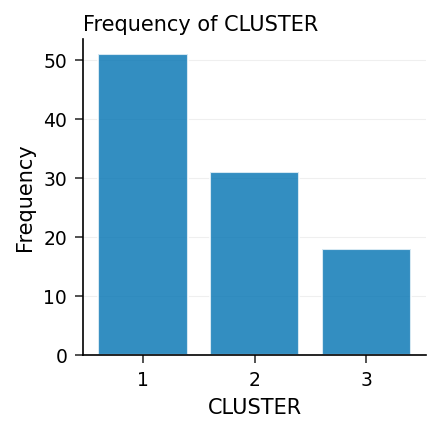

In [6]:
ΔΙΑΔΙΚΑΣΙΑ FASTCLUS ΔΕΔΟΜΕΝΑ=subs_std maxclusters=3 MAXITER=0 seed=seg_seeds
        out=rescored;
    ΜΕΤΑΒΛΗΤΗ tenure_months data_gb voice_min intl_min support_calls monthly_charge;
    id cust_id;
    ΕΤΙΚΕΤΑ tenure_months="Μήνες Παραμονής" data_gb="Δεδομένα (GB)" voice_min="Λεπτά Φωνής"
          intl_min="Διεθνή Λεπτά" support_calls="Κλήσεις Υποστήριξης" monthly_charge="Μηνιαία Χρέωση"
          cust_id="Αναγνωριστικό Συνδρομητή";
    TITLE 'Βαθμολόγηση Νέου Στιγμιότυπου από τα Εξαγόμενα Κεντροειδή';
ΕΚΤΕΛΕΣΗ;

ΔΙΑΔΙΚΑΣΙΑ ΣΥΧΝΟΤΗΤΕΣ ΔΕΔΟΜΕΝΑ=rescored;
    TABLES CLUSTER / nocum;
    ΕΤΙΚΕΤΑ CLUSTER="Συστάδα";
    TITLE 'Συνδρομητές που Επαναβαθμολογήθηκαν μέσω του Εξαγόμενου Μοντέλου';
ΕΚΤΕΛΕΣΗ;

## Ερμηνεία των αποτελεσμάτων

Η FASTCLUS ανέκτησε τα τρία συμπεριφορικά τμήματα που ήταν ενσωματωμένα στα δεδομένα, και οι πίνακες προφίλ τα μεταφράζουν σε ένα πλάνο διατήρησης πελατών. Διαβάστε τους αριθμούς τμημάτων από τον παραπάνω πίνακα *Προφίλ Τμημάτων* - οι ετικέτες συστάδων είναι αυθαίρετες, οπότε αναγνωρίστε κάθε περσόνα από το χαρακτηριστικό της χρήσης της:

- **Χρήστες χαμηλής χρήσης / value** - χαμηλά δεδομένα, μέτριοι λογαριασμοί, μεγαλύτερη παραμονή, πολύ λίγες κλήσεις υποστήριξης, κυρίως σε πακέτο *Βασικό*. Αυτοί οι πελάτες είναι σταθεροί και ευαίσθητοι στην τιμή· η σωστή κίνηση είναι να *προστατεύσουμε το περιθώριο κέρδους*, όχι να προσφέρουμε έκπτωση. Μια πρόταση κατάλληλου μεγέθους πακέτου αποτρέπει το σοκ του λογαριασμού χωρίς δωρεάν παροχές.
- **Χρήστες υψηλής χρήσης δεδομένων** - υψηλά δεδομένα, υψηλά λεπτά φωνής και διεθνών κλήσεων, premium λογαριασμοί, κυρίως σε πακέτο *Απεριόριστο*. Είναι πιστοί και υψηλής αξίας: η στρατηγική είναι *αναβάθμιση πακέτου και συσκευής*, καθώς και προληπτική ενημέρωση ποιότητας δικτύου ώστε καμία προσφορά ανταγωνιστή να μην τους αποσπάσει.
- **Συχνή επικοινωνία / κίνδυνος διαρροής** - μικρή παραμονή, αυξημένος όγκος κλήσεων υποστήριξης, μεσαία δαπάνη. Οι συχνές επαφές φροντίδας σε συνδυασμό με τη μικρή παραμονή είναι κλασικοί πρόδρομοι διαρροής. Αυτό είναι το τμήμα που αξίζει μια *προληπτική προσφορά διατήρησης* και παρακολούθηση αποκατάστασης υπηρεσίας.

Βασικές επιλογές διαδικασιών που το έκαναν αξιόπιστο: η **PROC STDIZE** εμπόδισε τα λεπτά φωνής μεγάλου μεγέθους να πνίξουν το σήμα των κλήσεων υποστήριξης· η σάρωση ψευδο-F τεκμηρίωσε τον αριθμό συστάδων αντί να τον μαντέψει· το βάρος `FREQ` έκανε τους οικογενειακούς λογαριασμούς πολλαπλών γραμμών να μετρούν ανάλογα με το αποτύπωμά τους· και ο κύκλος `OUTSEED=`/`SEED=` εξήγαγε τα κεντροειδή ώστε η ομάδα μάρκετινγκ να μπορεί να επανατμηματοποιεί κάθε μηνιαίο στιγμιότυπο με μία μόνο κλήση FASTCLUS με `MAXITER=0` - χωρίς να απαιτείται επανα-ομαδοποίηση.